In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving skin_temperature.csv to skin_temperature.csv
Saving spo2.csv to spo2.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
hr = pd.read_csv("heartrate.csv")
temp = pd.read_csv("skin_temperature.csv")
spo2 = pd.read_csv("spo2.csv")

print(hr.head())
print(temp.head())
print(spo2.head())

   val_0  val_1  val_2  val_3  val_4  val_5  val_6  val_7  val_8  val_9  ...  \
0    110     98    101    103     99    102    107    104    101     30  ...   
1    120    120    121    105    109    103    108    114    120    125  ...   
2    101     92     91    100    100     88     96     90     92     96  ...   
3     92     90     93     86     94     89     94     85     97    111  ...   
4    110    107    117    118    117    103    115     91     88     77  ...   

   val_21  val_22  val_23  val_24  val_25  val_26  val_27  val_28  val_29  \
0     102     106     107     117     108     100     106     104      92   
1     108     111     132     107     112     107     109     119     118   
2     103     109     112      95     100      92      87      92      97   
3     170     172     167     178     196     154      86      93     100   
4      30      70     108      96     110     116      96     112     109   

   label  
0   okay  
1   okay  
2   okay  
3    bad  
4

In [ ]:
hr_data = hr.drop("label", axis=1)
temp_data = temp.drop("label", axis=1)
spo2_data = spo2.drop("label", axis=1)

combined = pd.concat([hr_data, temp_data, spo2_data], axis=1)

In [ ]:
iso = IsolationForest(contamination=0.05)
anomaly_pred = iso.fit_predict(combined)

anomaly_flag = np.where(anomaly_pred == -1, 1, 0)

print("Total anomalies detected:", anomaly_flag.sum())

Total anomalies detected: 289


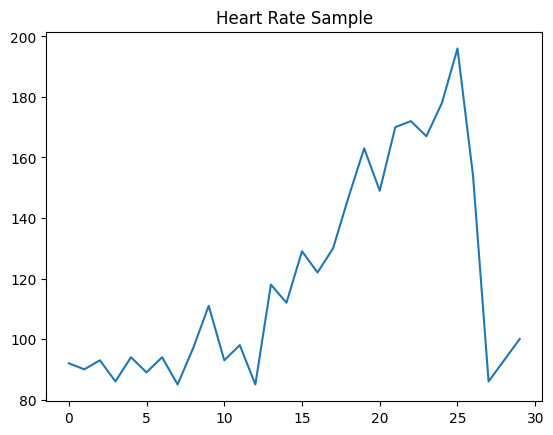

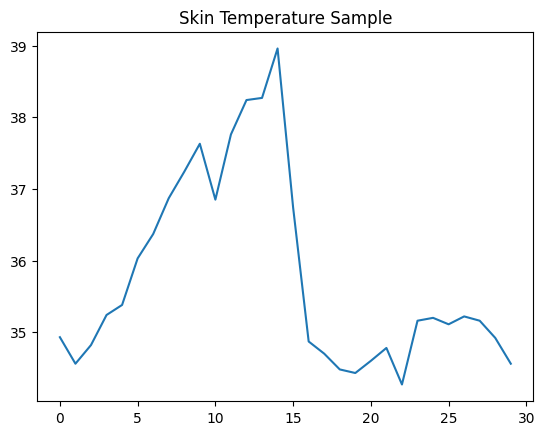

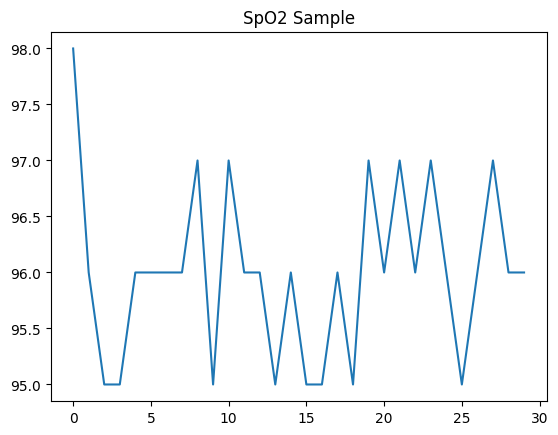

In [ ]:
sample_index = 3

plt.figure()
plt.plot(hr_data.iloc[sample_index].values)
plt.title("Heart Rate Sample")
plt.show()

plt.figure()
plt.plot(temp_data.iloc[sample_index].values)
plt.title("Skin Temperature Sample")
plt.show()

plt.figure()
plt.plot(spo2_data.iloc[sample_index].values)
plt.title("SpO2 Sample")
plt.show()

In [ ]:
le = LabelEncoder()
y = le.fit_transform(hr["label"])

X = hr_data.values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 30, 1)
X_test = X_test.reshape(X_test.shape[0], 30, 1)

model = Sequential()
model.add(LSTM(64, input_shape=(30,1)))
model.add(Dense(32, activation="relu"))
model.add(Dense(3, activation="softmax"))

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.fit(X_train, y_train, epochs=15, batch_size=32)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4673 - loss: 1.0297
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5675 - loss: 0.9261
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7015 - loss: 0.6333
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8018 - loss: 0.4209
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8100 - loss: 0.3970
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8280 - loss: 0.3650
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8353 - loss: 0.3573
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8461 - loss: 0.3373
Epoch 9/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8478 - loss: 0.3235
Epoch 10/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8558 - loss: 0.3059
Epoch 11/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8439 - loss: 0.3191
Epoch 12/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/ste

In [ ]:

hr_data = hr.drop("label", axis=1)

X_lstm = hr_data.values.reshape(hr_data.shape[0], 30, 1)

le = LabelEncoder()
y = le.fit_transform(hr["label"])

In [ ]:
person_id = 7   # change this number

sample = X_lstm[person_id].reshape(1,30,1)
prediction = model.predict(sample)

predicted_class = np.argmax(prediction)
health_status = le.inverse_transform([predicted_class])[0]

print("Predicted Health Status:", health_status)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Health Status: okay


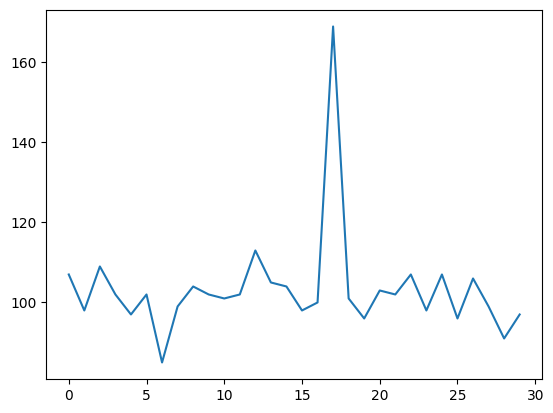

In [ ]:
plt.plot(hr_data.iloc[person_id].values)

In [ ]:
iso = IsolationForest(contamination=0.05)
anomaly = iso.fit_predict(X)

if anomaly[person_id] == -1:
    print("⚠️ Abnormal Vital Pattern Detected!")
else:
    print("✅ No Abnormal Pattern Detected")

✅ No Abnormal Pattern Detected


In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8906 - loss: 0.2571
Test Accuracy: 0.8836363554000854


In [ ]:
X_pred = hr_data.iloc[:, :29].values
y_pred = hr_data.iloc[:, 29].values

scaler = MinMaxScaler()
X_pred = scaler.fit_transform(X_pred)

X_pred = X_pred.reshape(X_pred.shape[0], 29, 1)

In [ ]:
model2 = Sequential()
model2.add(LSTM(50, input_shape=(29,1)))
model2.add(Dense(1))

model2.compile(optimizer="adam", loss="mse")
model2.fit(X_pred, y_pred, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9473.5400
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7118.5220
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 5926.4663
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 4782.5010
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 3842.6594
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3026.7019
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 2508.4128
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1996.3312
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1592.7289
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1262.0270


In [ ]:
test_sample = X_pred[0].reshape(1,29,1)
prediction = model2.predict(test_sample)

print("Predicted Next Heart Rate:", prediction[0][0])
print("Actual Next Heart Rate:", y_pred[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Next Heart Rate: 25.4111
Actual Next Heart Rate: 92


In [ ]:
print("\n----- HEALTH REPORT -----")

print("Health Status:", health_status)

if health_status == "okay":
    print("✅ Patient is Healthy.")
elif health_status == "warning":
    print("⚠️ Patient shows early warning signs.")
else:
    print("🚨 Patient is in critical condition!")

if prediction > 110:
    print("⚠️ Future Risk: Possible Tachycardia.")
elif prediction < 50:
    print("⚠️ Future Risk: Possible Bradycardia.")
else:
    print("✅ Future Heart Rate appears stable.")


----- HEALTH REPORT -----
Health Status: okay
✅ Patient is Healthy.
⚠️ Future Risk: Possible Bradycardia.
